# Final Baseline Analysis

In [ ]:
import warnings

from dagster_shared.utils.warnings import BetaWarning
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_model_family,
    parse_parameters,
)
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.plots.baseline_few_shot_comparison_plot import (
    baseline_few_shot_comparison_plot,
)
from social_groups.reporting.plots.baseline_method_comparison_plot import (
    baseline_method_comparison_plot,
)
import pandas as pd

warnings.filterwarnings("ignore", category=BetaWarning)

import social_groups.polars_columns as plc

%load_ext autoreload
%autoreload 2

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt


import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

In [ ]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
naive_parser = AnswerParser(AnswerOptions.letters_A_to_J_naive)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [ ]:
from social_groups.analysis.definitions import defs

final_baseline: pl.DataFrame = defs().load_asset_value("final_baseline")
baseline_paper_reported: pl.DataFrame = defs().load_asset_value(
    ["report", "external", "baseline_paper_reported"]
)

In [ ]:
baseline_paper_reported = baseline_paper_reported.cast({"Accuracy": pl.Float32})

Each combination of ["use_thinking", "with_few_shot_prompting", "model_name","generation_method"] is one experiment:

In [ ]:
assert (
    len(
        final_baseline.group_by(
            [
                "use_thinking",
                "with_few_shot_prompting",
                "model_name",
                "generation_method",
            ]
        )
        .agg(pl.col("run_id").unique().item())
        .select("run_id", pl.exclude("run_id"))
        .sort("run_id")
    )
    == 108
)

#### Regular Expressions used for parsing

In [ ]:
from social_groups.reporting.parsing import _ANSWER_PATTERNS
from social_groups.analysis.notebook_assets import (
    code_to_latex_snippet,
    definition_to_code_string,
)

register_materialization(
    "used_parsing_regular_expressions",
    code_to_latex_snippet(
        definition_to_code_string(
            _ANSWER_PATTERNS[AnswerOptions.letters_A_to_J],
            var_name="regular_expressions",
        ),
        caption="Regular Expressions used in parsing the LLM answers.",
        label="used_parsing_regular_expressions",
    ),
    "Code Snipped that shows the regular expressions used in the advanced parsing of llm answers.",
)

---

In [ ]:
with_parsed = final_baseline.with_columns(
    naive_parser(pl.col(plc.final_answer)).alias("Final Answer (Naive)"),
    parser(pl.col(plc.final_answer)).alias("Final Answer (Advanced)"),
    pl.col(plc.final_answer).str.slice(offset=-50).alias("end"),
).with_columns(
    comparer(pl.col("Final Answer (Naive)"), pl.col(plc.answer_string)).alias(
        "Is Correct (Naive)"
    ),
    comparer(pl.col("Final Answer (Advanced)"), pl.col(plc.answer_string)).alias(
        "Is Correct (Advanced)"
    ),
)

with_parsed.head()

In [ ]:
main_result = (
    with_parsed.group_by(
        [
            "use_thinking",
            "with_few_shot_prompting",
            "model_name",
            "generation_method",
        ]
    )
    .agg(
        pl.col("Is Correct (Naive)").mean().alias("Accuracy (Naive)") * 100,
        pl.col("Is Correct (Advanced)").mean().alias("Accuracy (Advanced)") * 100,
    )
    .sort("Accuracy (Advanced)", descending=True)
)

In [ ]:
def make_boolean_to_yes_no(column_name: str):
    return (
        pl.when(pl.col(column_name).is_null())
        .then(pl.lit(""))
        .when(pl.col(column_name))
        .then(pl.lit("Yes"))
        .otherwise(pl.lit("No"))
        .alias(column_name)
    )

In [ ]:
def make_pretty(df):
    return (
        df.with_columns(
            pl.col("model_name")
            .str.extract(r"/(Qwen[0-9.]*|Ministral-3)")
            .alias("Family"),
            pl.col("model_name")
            .str.split("/")
            .list.last()
            .str.replace("-Reasoning-2512", ""),
            pl.col("generation_method").replace(
                {
                    "structured-output": "Structured Output",
                    "tool": "Tool",
                    "standard": "Chat Completion",
                }
            ),
            make_boolean_to_yes_no("use_thinking"),
            make_boolean_to_yes_no("with_few_shot_prompting"),
        )
        .rename(
            {
                "model_name": "Model",
                "with_few_shot_prompting": "Few Shot Prompting",
                "use_thinking": "Reasoning",
                "generation_method": "Method",
            }
        )
        .select("Family", "Model", "Method", pl.exclude("Family", "Model", "Method"))
        .sort("Accuracy (Advanced)", "Accuracy (Naive)", descending=True)
    )

In [ ]:
pretty_main = make_pretty(main_result)
register_materialization(
    "baseline_accuracy_overview_all_with_parsing",
    pretty_main,
    "Overview of the achieved accuracy on MMLUPro for different baseline parameters and parsing methods.",
)

In [ ]:
(
    main_result.with_columns(
        pl.col("model_name").str.extract(r"/(Qwen[0-9.]*|Ministral-3)").alias("Family")
    )
    .fill_null(False)
    .with_columns(
        pl.concat_str(
            [
                pl.when(pl.col("use_thinking"))
                .then(pl.lit("R"))
                .otherwise(pl.lit("x")),
                pl.when(pl.col("with_few_shot_prompting"))
                .then(pl.lit("F"))
                .otherwise(pl.lit("x")),
            ]
        ).alias("combination")
    )
).head()

In [ ]:
g = baseline_method_comparison_plot(main_result)
register_materialization(
    "baseline_method_comparison_plot",
    g,
    "Overview of the different baselines for the different families, generation methods and methods of parsing",
)

### Improvement of Advanced Parsing and Few Shot Learning

In [ ]:
g2 = baseline_few_shot_comparison_plot(pretty_main)
register_materialization(
    "baseline_few_shot_comparison_plot",
    g2,
    "Shows the differences in changing Parsing of Few-Shot Method on the performance for different models and reasoning settings.",
)

## Relevance of Parsing Errors in the Answers

In [ ]:
with_parsed["Final Answer (Advanced)"].unique()

In [ ]:
# unusable Ministral3 Instruct Model in Structured Output mode

with_parsed.filter(
    pl.col("model_name") == "mistralai/Ministral-3-8B-Reasoning-2512"
).filter(pl.col("use_thinking") == False).filter(
    pl.col("generation_method") == "structured-output"
)

In [ ]:
with_parsed.filter(pl.col("model_name") == "Qwen/Qwen3-14B").filter(
    pl.col("generation_method") == "tool"
)

In [ ]:
def has_repeated_substring_hash(SUBSTRING_LENGTH: int):
    def foo(s: str) -> bool:
        if s is None or len(s) < 2 * SUBSTRING_LENGTH:
            return False

        seen = set()

        for i in range(len(s) - SUBSTRING_LENGTH + 1):
            h = hash(s[i : i + SUBSTRING_LENGTH])

            if h in seen:
                return True

            seen.add(h)

        return False

    return foo


def find_repeated_substring(SUBSTRING_LENGTH: int):
    def foo(s: str) -> str | None:
        if s is None or len(s) < 2 * SUBSTRING_LENGTH:
            return None

        seen = set()

        for i in range(len(s) - SUBSTRING_LENGTH + 1):
            h = hash(s[i : i + SUBSTRING_LENGTH])

            if h in seen:
                return s[i : i + SUBSTRING_LENGTH]

            seen.add(h)

        return None

    return foo

In [ ]:
parsing_error_info = (
    with_parsed.with_columns(
        pl.when(pl.col("Final Answer (Naive)") == "___not_parsable___")
        .then(True)
        .when(pl.col("Final Answer (Naive)").is_null())
        .then(True)  # TODO: mybe change to NONE
        .otherwise(False)
        .alias("is_parsing_error_naive"),
        pl.when(pl.col("Final Answer (Advanced)") == "___not_parsable___")
        .then(True)
        .when(pl.col("Final Answer (Advanced)").is_null())
        .then(True)  # TODO: mybe change to NONE
        .otherwise(False)
        .alias("is_parsing_error_advanced"),
        (
            pl.col("used_output_tokens")
            == (pl.col("used_output_tokens").max()).over(
                [
                    "use_thinking",
                    "with_few_shot_prompting",
                    "model_name",
                    "generation_method",
                ]
            )
        ).alias("hit_max_tokens"),
        pl.col("final_answer")
        .map_elements(has_repeated_substring_hash(200))
        .fill_null(False)
        .alias("is_stuck_repetition_answer"),
    )
    # .group_by(
    #     [
    #         "use_thinking",
    #         "with_few_shot_prompting",
    #         "model_name",
    #         "generation_method",
    #     ]
    # )
    # .agg(
    #     pl.col("is_parsing_error_naive").mean(),
    #     pl.col("is_parsing_error_advanced").mean(),
    #     pl.col("is_parsing_error_naive").is_null().mean().alias("is_null_naive"),
    #     pl.col("is_parsing_error_advanced").is_null().mean().alias("is_null_advanced"),
    #     # pl.col("is_parsing_error_naive")
    #     # .drop_nulls()
    #     # .mean()
    #     # .alias("is_parsing_error_naive_given_not_null"),
    #     # pl.col("is_parsing_error_advanced")
    #     # .drop_nulls()
    #     # .mean()
    #     # .alias("is_parsing_error_advanced_given_not_null"),
    #     pl.col("hit_max_tokens").mean(),
    #     pl.col("is_stuck_repetition_answer").mean(),
    # )
)

# pl.testing.assert_series_equal(
#     parsing_error_info["is_null_naive"],
#     parsing_error_info["is_null_advanced"],
#     check_names=False,
# )
# parsing_error_info = parsing_error_info.with_columns(
#     pl.col("is_null_naive").alias("is_null_percentage")
# ).drop("is_null_naive", "is_null_advanced")

parsing_error_info.head()

In [ ]:
import polars as pl
import pandas as pd

df = parsing_error_info

# Choose which parsing error definition to use
# (or combine them)
df = df.with_columns(
    [
        (pl.col("is_parsing_error_naive") | pl.col("is_parsing_error_advanced")).alias(
            "is_parsing_error"
        )
    ]
)

pdf = df.to_pandas()

summary = {
    "P(parse_error | max_tokens)": (
        pdf.loc[pdf.hit_max_tokens, "is_parsing_error"].mean()
    ),
    "P(parse_error | NOT max_tokens)": (
        pdf.loc[~pdf.hit_max_tokens, "is_parsing_error"].mean()
    ),
    "P(max_tokens | repetition)": (
        pdf.loc[pdf.is_stuck_repetition_answer, "hit_max_tokens"].mean()
    ),
    "P(max_tokens | NOT repetition)": (
        pdf.loc[~pdf.is_stuck_repetition_answer, "hit_max_tokens"].mean()
    ),
}

print(summary)

In [ ]:
import plotly.graph_objects as go
import pandas as pd

tmp = pdf.copy()

# Nodes:
# 0 Normal
# 1 Repetition
# 2 Hit Max Tokens
# 3 Parsing Error

n_normal = (~tmp.is_stuck_repetition_answer).sum()
n_rep = tmp.is_stuck_repetition_answer.sum()

rep_and_max = (tmp.is_stuck_repetition_answer & tmp.hit_max_tokens).sum()

rep_no_max = (tmp.is_stuck_repetition_answer & ~tmp.hit_max_tokens).sum()

max_and_parse = (tmp.hit_max_tokens & tmp.is_parsing_error).sum()

max_no_parse = (tmp.hit_max_tokens & ~tmp.is_parsing_error).sum()

nonmax_parse = (~tmp.hit_max_tokens & tmp.is_parsing_error).sum()

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=25,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=[
                    "No Repetition",
                    "Repetition",
                    "Hit Max Tokens",
                    "Parsing Error",
                ],
            ),
            link=dict(
                source=[
                    1,  # repetition -> max
                    1,  # repetition -> no max (implicit)
                    2,  # max -> parse
                ],
                target=[
                    2,
                    0,
                    3,
                ],
                value=[
                    rep_and_max,
                    rep_no_max,
                    max_and_parse,
                ],
            ),
        )
    ]
)

fig.update_layout(
    title="Failure Pathway Analysis",
    font_size=14,
    width=900,
    height=500,
)

fig.show()

In [ ]:
pdf.head()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def draw_heatmap_by_method(column_used):

    tmp = pdf.copy()

    tmp["model_name"] = tmp["model_name"] + tmp["use_thinking"].case_when(
        [
            (tmp["use_thinking"].eq(1), " (R)"),
            (
                tmp["use_thinking"].eq(0),
                "",
            ),
        ]
    )
    tmp["generation_method"] = tmp["generation_method"] + tmp[
        "with_few_shot_prompting"
    ].case_when(
        [
            (tmp["with_few_shot_prompting"].eq(1), " (5-shot)"),
            (
                tmp["with_few_shot_prompting"].eq(0),
                " (0-shot)",
            ),
        ]
    )

    grouped = (
        tmp.dropna(subset=[column_used])
        .groupby(["model_name", "generation_method"])[column_used]
        .mean()
        .reset_index()
    )

    pivot = grouped.pivot(
        index="model_name", columns="generation_method", values=column_used
    )

    plt.figure(figsize=(10, 6))

    sns.heatmap(pivot, annot=True, fmt=".2%", cmap="Reds")

    plt.title(f"{column_used} Rate by Model and Generation Method")
    plt.xlabel("Generation Method")
    plt.ylabel("Model")

    plt.show()


draw_heatmap_by_method("is_parsing_error_advanced")

In [ ]:
draw_heatmap_by_method("hit_max_tokens")

In [ ]:
draw_heatmap_by_method("is_stuck_repetition_answer")

In [ ]:
import statsmodels.formula.api as smf

smfpdf = df.with_columns(
    [
        # Combined parsing error target
        (pl.col("is_parsing_error_naive") | pl.col("is_parsing_error_advanced"))
        .cast(pl.Int8)
        .alias("is_parsing_error"),
        # Convert predictors too
        pl.col("hit_max_tokens").cast(pl.Int8),
        pl.col("is_stuck_repetition_answer").cast(pl.Int8),
        pl.col("with_few_shot_prompting").cast(pl.Int8),
        pl.col("use_thinking").cast(pl.Int8),
    ]
).to_pandas()

model = smf.logit(
    """
    is_parsing_error ~
    hit_max_tokens +
    is_stuck_repetition_answer +
    C(model_name) +
    C(generation_method)
    """,
    data=smfpdf,
).fit()

print(model.summary())

interaction_model = smf.logit(
    """
    is_parsing_error ~
    hit_max_tokens *
    is_stuck_repetition_answer +
    C(model_name) *
    C(generation_method)
    """,
    data=smfpdf,
).fit()

print(interaction_model.summary())

### Comparing With Reported Results

In [ ]:
reported_pretty = (
    (
        baseline_paper_reported.filter(pl.col("Dataset") == "MMLUPro")
        .drop("Dataset")
        .with_columns(
            base_name=pl.col("Model").str.split(" ").list.first(),
        )
        .with_columns(
            pl.col("base_name").str.split("-").list.first().alias("Model Family"),
            pl.col("base_name").str.split("-").list.last().alias("Parameters"),
        )
        .rename({"Accuracy": "Reported Accuracy (Original MMLUPro)"})
        .drop("base_name", "Model")
    )
    .join(
        (
            main_result.filter(pl.col("with_few_shot_prompting") == True)
            .filter(pl.col("use_thinking") == False)
            .filter(pl.col("generation_method") == "standard")
            .with_columns(
                parse_model_family(pl.col("model_name")).alias("Model Family"),
                (parse_parameters(pl.col("model_name")).cast(str) + pl.lit("B"))
                .str.replace(".0B", "B")
                .alias("Parameters"),
            )
            .drop(
                "generation_method",
                "model_name",
                "with_few_shot_prompting",
                "use_thinking",
            )
        ),
        on=["Model Family", "Parameters"],
        how="left",
    )
    .select(
        "Model Family",
        "Parameters",
        "Source",
        pl.col("Reported Accuracy (Original MMLUPro)").round(1),
        pl.col("Accuracy (Naive)")
        .alias("Accuracy (Naive, Adapted MMLUPro-1000-Subset)")
        .round(1),
        pl.col("Accuracy (Advanced)")
        .alias("Accuracy (Advanced, Adapted MMLUPro-1000-Subset)")
        .round(1),
    )
    .cast(str)
    .fill_null(" - ")
)

reported_pretty

In [ ]:
register_materialization(
    "baseline_comparison_with_reported_numbers",
    reported_pretty,
    "Baseline Experiments Accuracy Compared to the reported numbers released by the model publisher",
)

## Order models into L,M,H:

In [272]:
with_model_category = (
    main_result.filter(pl.col("with_few_shot_prompting") == True)
    .filter(pl.col("generation_method") == "standard")
    .group_by("model_name")
    .agg(
        pl.col("Accuracy (Advanced)").filter(pl.col("use_thinking") == False).item().alias("Accuracy (Reasoning)"),
        pl.col("Accuracy (Advanced)").filter(pl.col("use_thinking") == True).item().alias("Accuracy"),
    )
    .with_columns(
        parse_model_family(pl.col("model_name")).alias("Family"),
        parse_parameters(pl.col("model_name")).alias("Parameters"),
        pl.col("model_name")
        .replace(MODEL_NAME_TO_LETTER_MAPPING)
        .alias("Model Category"),
    )
    .sort("Accuracy")
    .group_by("Family")
    .agg(
        pl.col("Accuracy").rank().cast(str).alias("Rank").replace({1.0: "L", 2.0: "M", 3.0: "H"}),
        pl.col("Accuracy (Reasoning)").rank().cast(str).alias("Rank (Reasoning)").replace({1.0: "L", 2.0: "M", 3.0: "H"}),
        pl.col("Parameters"),
        pl.col("Accuracy").implode(),
        pl.col("Accuracy (Reasoning)").implode(),
    )
    .explode("Parameters", "Accuracy", "Rank", "Accuracy (Reasoning)", "Rank (Reasoning)")
    .select("Family", "Parameters", "Accuracy", "Rank", "Accuracy (Reasoning)", "Rank (Reasoning)")
)

register_materialization(
    "baseline_standard_ordering_into_LMH_groups",
    with_model_category,
    "Baseline Experiments standard generation with ranks according to their performance inside the family.",
)

with_model_category.sort("Accuracy")

Skipping Materialization because in interactive mode.


Family,Parameters,Accuracy,Rank,Accuracy (Reasoning),Rank (Reasoning)
str,f64,f64,str,f64,str
"""Qwen3.5""",0.8,14.5,"""L""",35.0,"""L"""
"""Qwen3""",0.6,31.4,"""L""",26.9,"""L"""
"""Ministral""",3.0,43.6,"""L""",50.9,"""L"""
"""Qwen3.5""",4.0,62.9,"""M""",71.8,"""M"""
"""Qwen3""",4.0,63.1,"""M""",56.8,"""M"""
"""Ministral""",8.0,63.2,"""M""",67.8,"""M"""
"""Qwen3.5""",9.0,66.9,"""H""",77.6,"""H"""
"""Ministral""",14.0,68.1,"""H""",71.4,"""H"""
"""Qwen3""",14.0,73.3,"""H""",69.6,"""H"""


,## Comparing the Knowledge Difference

In [267]:
from social_groups.analysis.polars_transformations.tests.assert_one_to_one_mapping import (
    assert_one_to_one_mapping,
)

knowledge_differences = (
    with_parsed.select(
        [
            "model_name",
            "with_few_shot_prompting",
            "use_thinking",
            "generation_method",
            "question_id",
            "original_question_id",
            "category",
            "answer_string",
            "Final Answer (Advanced)",
            "Is Correct (Advanced)",
        ]
    )
    .rename(
        {
            "Final Answer (Advanced)": "final_answer",
            "Is Correct (Advanced)": "is_correct",
        }
    )
    .with_columns(
        pl.concat_str(
            [
                pl.when(pl.col("use_thinking"))
                .then(pl.lit("R"))
                .otherwise(pl.lit("x")),
                pl.when(pl.col("with_few_shot_prompting"))
                .then(pl.lit("F"))
                .otherwise(pl.lit("x")),
            ]
        ).alias("combination")
    )
    .drop(["use_thinking", "with_few_shot_prompting"])
)

assert_one_to_one_mapping(knowledge_differences, "question_id", "original_question_id")

knowledge_differences = knowledge_differences.drop("question_id")

knowledge_differences.head()

✅ Assertion passed: question_id ↔ original_question_id is a strict 1-1 mapping.


model_name,generation_method,original_question_id,category,answer_string,final_answer,is_correct,combination
str,str,i64,str,str,str,bool,str
"""Qwen/Qwen3.5-9B""","""standard""",5035,"""history""","""C""","""C""",true,"""xx"""
"""Qwen/Qwen3.5-9B""","""standard""",4077,"""chemistry""","""C""","""C""",true,"""xx"""
"""Qwen/Qwen3.5-9B""","""standard""",8052,"""math""","""D""","""D""",true,"""xx"""
"""Qwen/Qwen3.5-9B""","""standard""",11306,"""engineering""","""A""","""___not_parsable___""",false,"""xx"""
"""Qwen/Qwen3.5-9B""","""standard""",9737,"""physics""","""A""","""A""",true,"""xx"""


In [ ]:
question_overview = (
    knowledge_differences.filter(pl.col("generation_method") == "standard")
    .with_columns(
        (pl.col("model_name") + pl.lit(" | ") + pl.col("combination"))
        .str.split("/")
        .list.last()
        .str.replace("-Reasoning-2512", "")
        .alias("label"),
    )
    .drop(
        [
            "answer_string",
            "final_answer",
            "generation_method",
            "model_name",
            "combination",
            "category",
        ]
    )
    .sort("original_question_id")
)
question_overview

Skipping Materialization because in interactive mode.


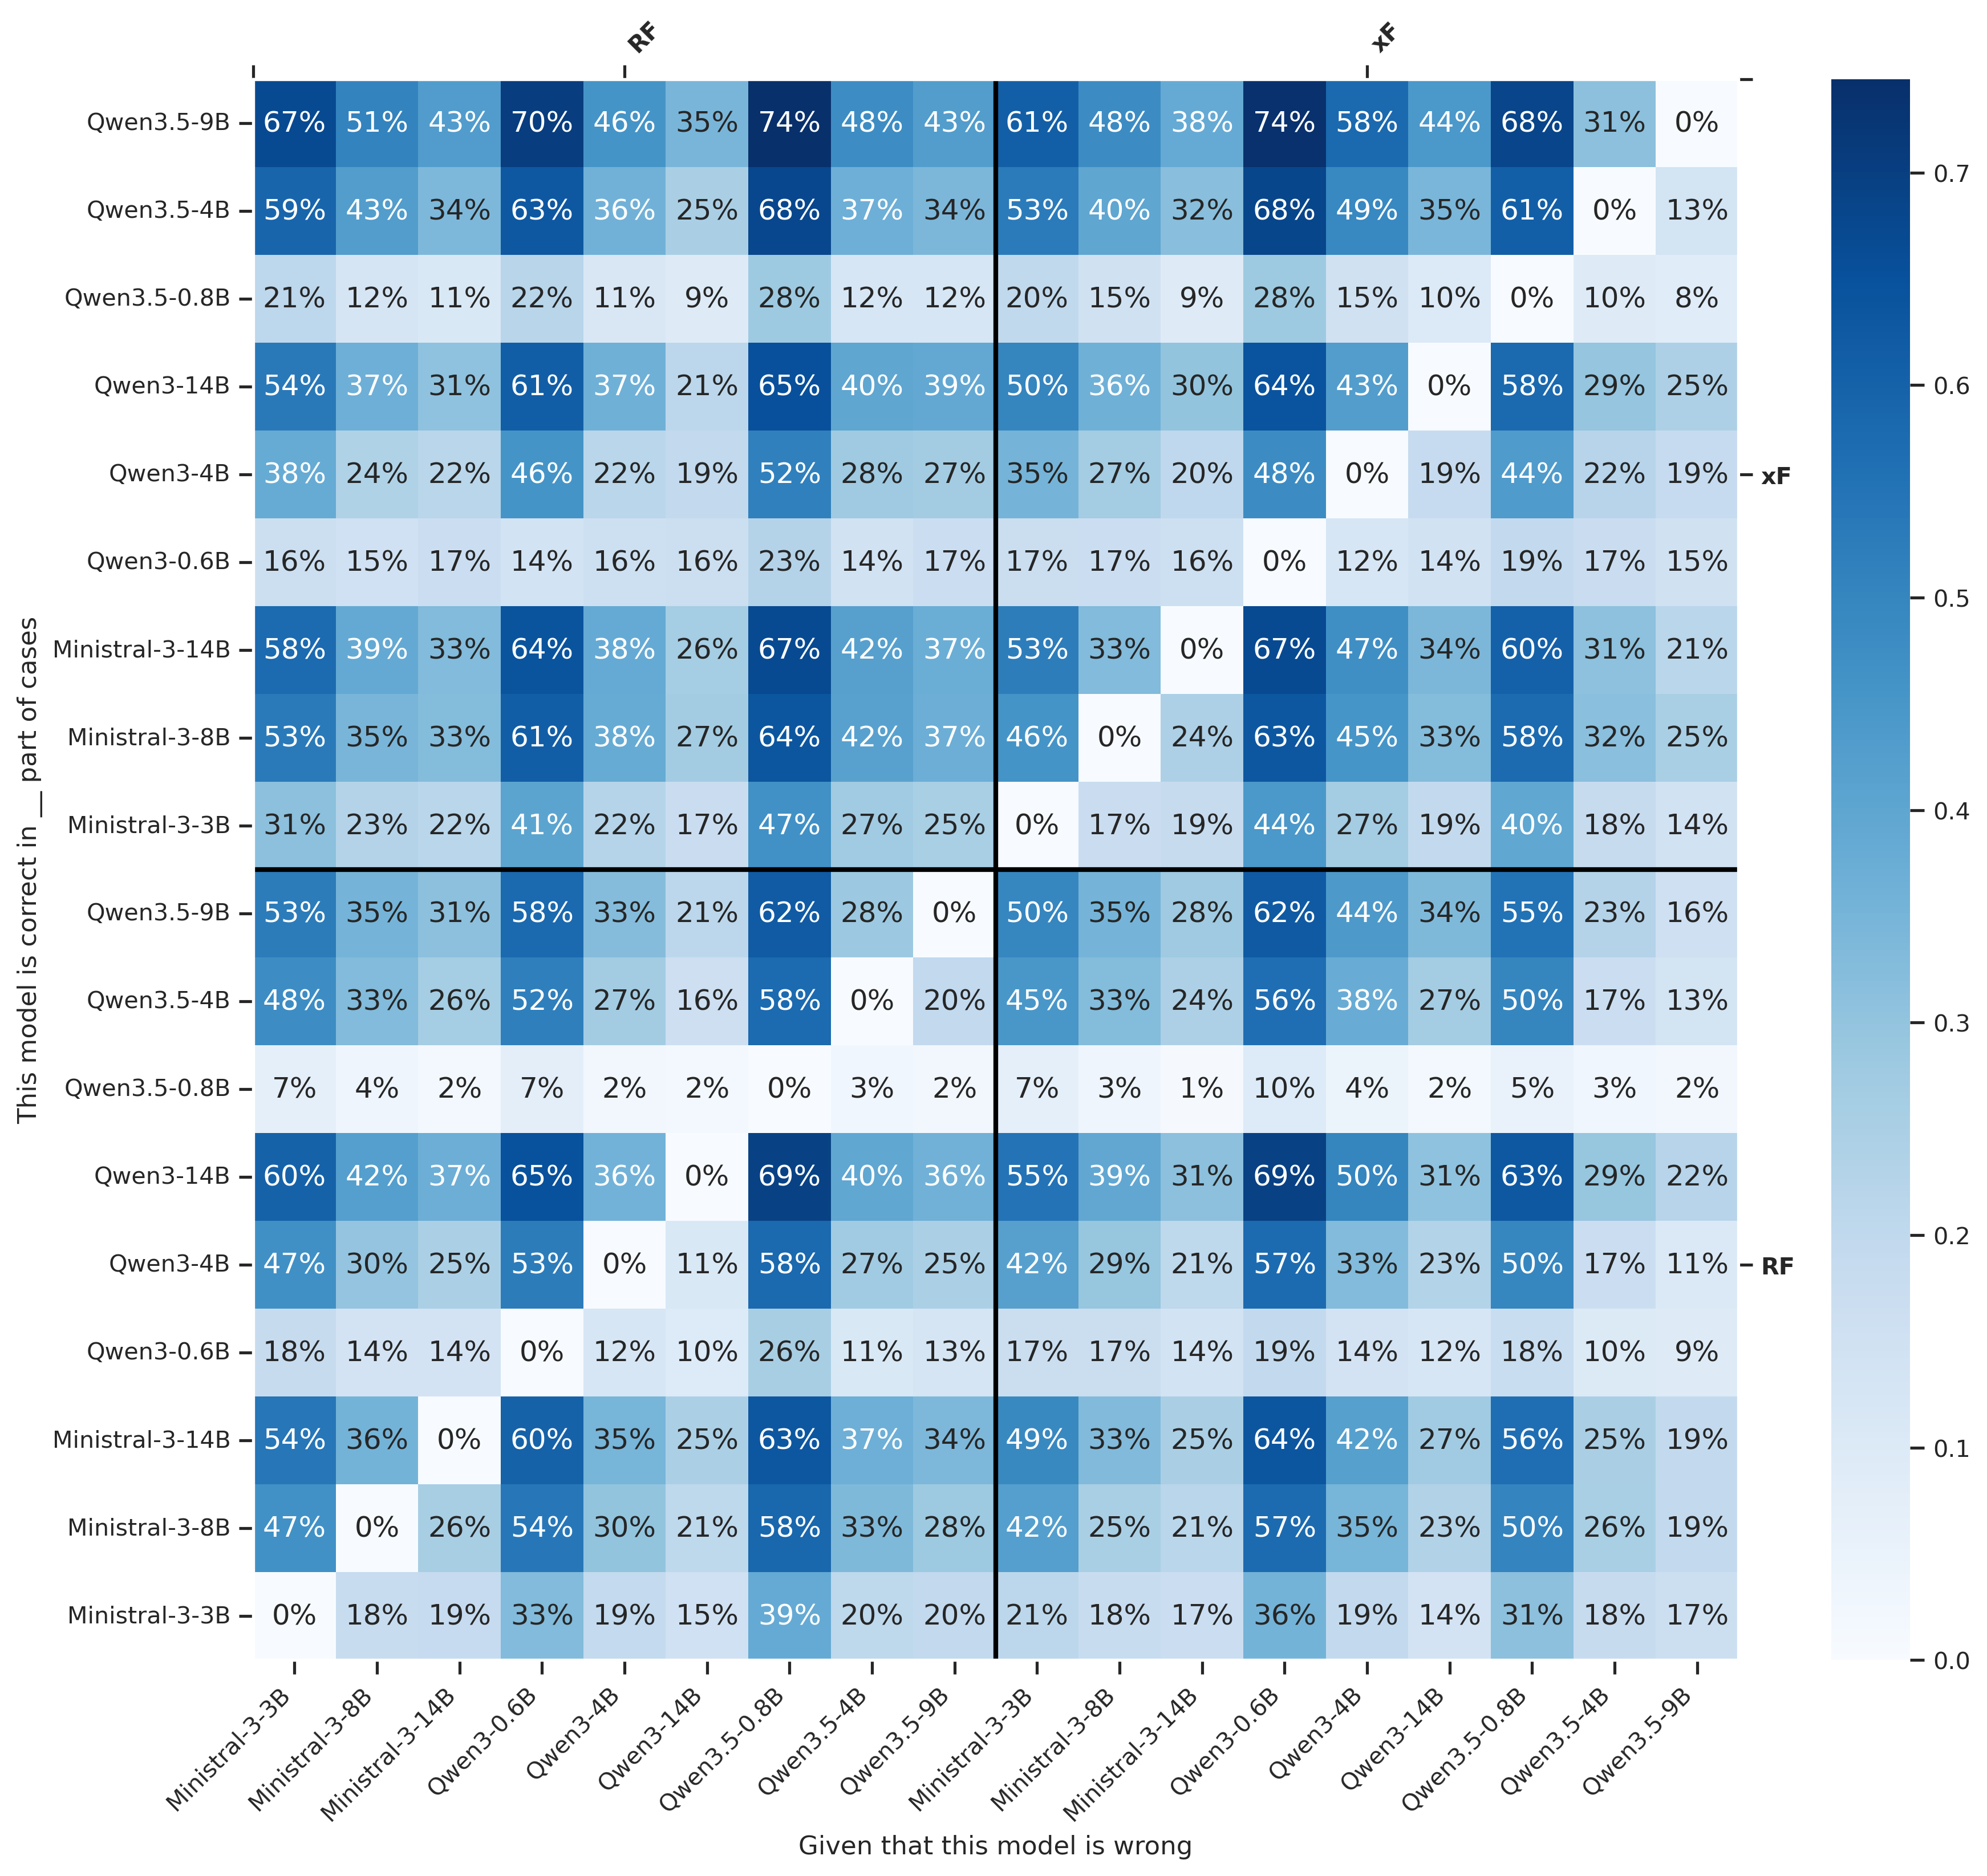

In [271]:
from social_groups.reporting.plots.baseline_structural_black_hole_plot import (
    baseline_structural_black_hole_plot,
)

g = baseline_structural_black_hole_plot(knowledge_differences.filter(pl.col("generation_method") == "standard").filter(pl.col("combination").is_in({"RF", "xF"})))
register_materialization(
    "baseline_structural_black_hole_plot",
    g,
    "Overview of the additional correct answers that can be provided by a given model, assuming that another one is wrong. (Baseline Experiments)",
)

In [ ]:
CASE = "xx"

df = question_overview.filter(pl.col("label").str.contains(CASE)).with_columns(
    pl.col("label").str.replace(f" \| {CASE}", "")
)

# 1. Map Questions to ranks (0-999) and Students to indices (0-8)
df_transformed = (
    df.filter(pl.col("is_correct") == True)
    # Assign a unique rank to each question ID
    .with_columns(
        pl.col("original_question_id")
        .rank("dense")
        .cast(pl.Int64)
        .sub(1)
        .alias("q_rank")
    )
    # Assign a 0-8 index to each student
    .with_columns(pl.col("label").rank("dense").cast(pl.Int64).sub(1).alias("s_idx"))
    # Calculate grid positions
    .with_columns(
        [
            # Macro-position (The question's cell)
            (pl.col("q_rank") % 32).alias("macro_x"),
            (pl.col("q_rank") // 32).alias("macro_y"),
            # Micro-position (The student's slot within the cell)
            (pl.col("s_idx") % 3).alias("dx"),
            (pl.col("s_idx") // 3).alias("dy"),
        ]
    )
    # Combine them (we multiply by 4 to leave 1px of "air" between question blocks)
    .with_columns(
        [
            (pl.col("macro_x") * 4 + pl.col("dx")).alias("final_x"),
            (pl.col("macro_y") * 4 + pl.col("dy")).alias("final_y"),
        ]
    )
)

# 2. Visualize
plt.figure(figsize=(14, 14))
plot = sns.scatterplot(
    data=df_transformed.to_pandas(),
    x="final_x",
    y="final_y",
    hue="label",
    marker="s",  # Square marker
    s=12,  # Size of the student dots
    linewidth=0,  # Remove borders for a cleaner "pixel art" look
    alpha=0.9,
    palette="muted",
)

# Reverse Y axis so the first question is at the top-left
plt.gca().invert_yaxis()
plt.axis("off")  # Remove axes to emphasize the "fingerprint" pattern
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Students")
plt.tight_layout(pad=0)
plt.show()

plot.figure.savefig("tmp.png")

In [ ]:
plt.figure(figsize=(14, 10))

df = (
    knowledge_differences.filter(pl.col("generation_method") == "standard")
    .sort("category")
    .with_columns(
        (pl.col("model_name") + pl.lit(" | ") + pl.col("combination")).alias("y_label"),
    )
    .drop(
        [
            "answer_string",
            "final_answer",
            "generation_method",
            "model_name",
            "combination",
        ]
    )
    .drop("original_question_id")
    .group_by("y_label", "category")
    .agg(pl.col("is_correct").mean())
)

matrix = (
    df.pivot(
        index="y_label",
        columns="category",
        values="is_correct",
        aggregate_function="item",
    )
    .with_columns(
        sorting1=pl.col("y_label")
        .str.split("/")
        .list.last()
        .str.split("-")
        .list.first(),
        sorting2=pl.col("y_label")
        .str.split("|")
        .list.first()
        .str.split("-")
        .list.filter(pl.element().str.contains("B"))
        .list.item()
        .str.replace("B", "")
        .str.strip_chars()
        .cast(float),
        sorting3=pl.col("y_label").str.split("|").list.last(),
    )
    .sort("sorting3", "sorting1", "sorting2", descending=True)
    .drop("sorting1", "sorting2", "sorting3")
)

z = matrix.drop("y_label").to_numpy().astype(float)
y_labels = matrix["y_label"].to_list()
x_labels = matrix.columns

sns.heatmap(
    z,
    # cmap=["white", "black"],  # white → black
    cbar=True,
    linewidths=0.1,  # very fine grid lines between cells
    linecolor="lightgray",
    yticklabels=y_labels,
    xticklabels=x_labels,
    # xticklabels=100,  # show label every 100 questions
)

plt.title("Correct Answers per Question")
plt.show()
plt.savefig("tmp.png")

-----

### TODO: further analyze this.
- When using tool, the few shot prompting often produces the absolutely exact same result.
- this could be analyzed further

In [ ]:
(
    final_baseline.group_by("final_answer")
    .agg(
        pl.col("with_few_shot_prompting").implode().list.unique(),
        pl.col("use_thinking").implode().list.unique(),
        pl.col("generation_method").implode().list.unique(),
        count=pl.len(),
        used_from=pl.col("model_name").implode().list.unique(),
    )
    .with_columns(used_by=pl.col("used_from").list.len())
    .filter(pl.col("count") > 1)
    .sort("count", descending=True)
    # .filter(pl.col("used_by") == 1)
    # .drop("used_by")
    # .filter(pl.col("count") == 2)
    # .drop("count")
)